# MAgent2 Torch Robust MF-DSRQ Training

Train the Torch-native robust-action mean-field SRQ variant on `battle_v4` for four fixed robust epsilon values. Each epsilon gets its own run directory, reward/win plot, and final kill-rule win-rate summary.

In [1]:
from pathlib import Path
import sys


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "discrete_action_space").is_dir() and (path / "requirements.txt").exists():
            return path
    raise RuntimeError("Could not find the SRE-DQN repo root from the current notebook directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from discrete_action_space.mean_field_dsrq.notebook_utils import (
    mfdsrq_epsilon_config,
    notebook_mfdsrq_config,
    plot_mfdsrq_training_curves,
    print_mfdsrq_training_win_rates,
    train_mfdsrq_from_notebook,
)

NUM_EPISODES = 2000
MAX_CYCLES = 400
NUM_ENVS = 16
MAP_SIZE = 40
SEED = 42
ALGORITHM = "mf_srq_torch"
ROBUST_DISTANCE = "tv"
ROBUST_POLICY_TEMPERATURE = 0.1
SMOOTHING_WINDOW = 20
EPSILONS = [0.01, 0.1, 0.5, 1.0]

OUTPUT_ROOT = ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs" / "mf_srq_torch_epsilon_training"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

BASE_CFG = notebook_mfdsrq_config(
    target_episodes=NUM_EPISODES,
    num_envs=NUM_ENVS,
    map_size=MAP_SIZE,
    max_cycles=MAX_CYCLES,
    output_dir=OUTPUT_ROOT,
    seed=SEED,
    extra_overrides={
        "algorithm": ALGORITHM,
        "robust_policy_temperature": ROBUST_POLICY_TEMPERATURE,
        "batch_size": 256,
        "max_train_batches_per_update": None,
    },
)

MFDSRQ_TORCH_RESULTS = {}
BASE_CFG


{'algorithm': 'mf_srq_torch',
 'env_name': 'battle_v4',
 'env_backend': 'magent2',
 'map_size': 40,
 'max_cycles': 400,
 'type_prefixes': {'red': 'red_', 'blue': 'blue_'},
 'mean_field_source': 'opponent',
 'epsilon_robust_start': 0.1,
 'epsilon_robust_end': 0.02,
 'epsilon_robust_decay_frac': 1.0,
 'robust_distance': 'tv',
 'robust_lp_fallback': 'greedy_tv',
 'robust_policy_cache_enabled': True,
 'robust_policy_cache_size': 4096,
 'robust_policy_cache_round_digits': 6,
 'epsilon_explore_start': 1.0,
 'epsilon_explore_mid': 0.2,
 'epsilon_explore_mid_fraction': 0.8,
 'epsilon_explore_end': 0.1,
 'gamma': 0.95,
 'lr': 0.0001,
 'batch_size': 256,
 'buffer_capacity': 80000,
 'learning_starts': 5000,
 'train_every': 5,
 'target_tau': 0.005,
 'grad_clip': 10.0,
 'target_episodes': 2000,
 'num_envs': 16,
 'seed': 42,
 'self_play_tau': 0.01,
 'max_train_batches_per_update': None,
 'output_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training

## Robust Epsilon 0.01

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-746.763 mean_opponent_reward=-743.886 loss=0.0285 episodes_per_sec=0.47
[mf_srq_torch] episodes=800/2000 mean_main_reward=15.521 mean_opponent_reward=13.998 loss=0.5743 episodes_per_sec=0.46
[mf_srq_torch] episodes=1200/2000 mean_main_reward=210.200 mean_opponent_reward=192.889 loss=0.4500 episodes_per_sec=0.47
[mf_srq_torch] episodes=1600/2000 mean_main_reward=158.980 mean_opponent_reward=168.126 loss=0.3289 episodes_per_sec=0.50
[mf_srq_torch] episodes=2000/2000 mean_main_reward=179.656 mean_opponent_reward=185.731 loss=0.2616 episodes_per_sec=0.52

Training complete. 2000 episodes, 510,903 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42/training_stats.json
Saved training curves t

{'main': 0.5255, 'opponent': 0.427}

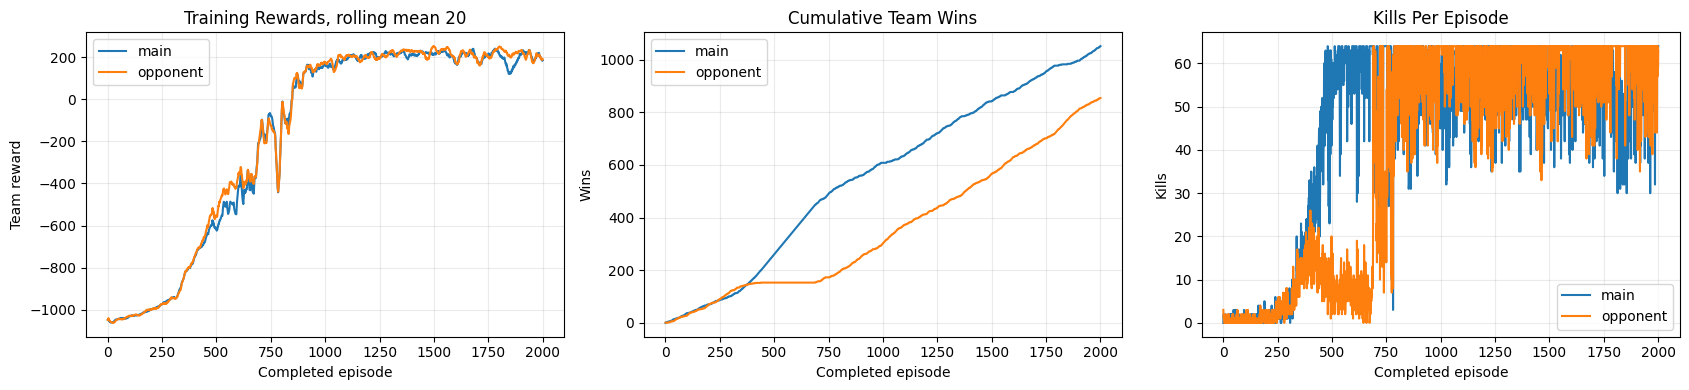

In [2]:
epsilon = 0.01
cfg_eps_0_01 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_01 = train_mfdsrq_from_notebook(cfg_eps_0_01)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_01
plot_mfdsrq_training_curves(result_eps_0_01, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_01)


## Robust Epsilon 0.1

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-853.982 mean_opponent_reward=-851.487 loss=0.0159 episodes_per_sec=0.47
[mf_srq_torch] episodes=800/2000 mean_main_reward=-21.068 mean_opponent_reward=-53.684 loss=0.2186 episodes_per_sec=0.43
[mf_srq_torch] episodes=1200/2000 mean_main_reward=187.655 mean_opponent_reward=228.257 loss=0.5067 episodes_per_sec=0.46
[mf_srq_torch] episodes=1600/2000 mean_main_reward=249.282 mean_opponent_reward=216.549 loss=0.4776 episodes_per_sec=0.49
[mf_srq_torch] episodes=2000/2000 mean_main_reward=260.667 mean_opponent_reward=250.560 loss=0.4697 episodes_per_sec=0.50

Training complete. 2000 episodes, 481,577 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_1/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_1/battle_v4/seed42/training_stats.json
Saved training curves t

{'main': 0.488, 'opponent': 0.4575}

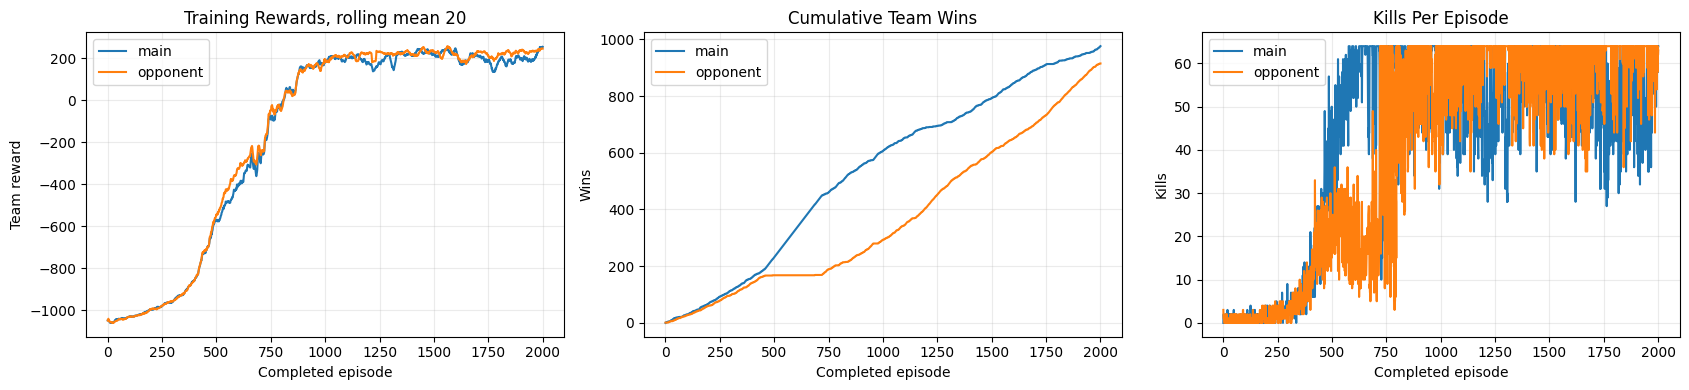

In [3]:
epsilon = 0.1
cfg_eps_0_1 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_1 = train_mfdsrq_from_notebook(cfg_eps_0_1)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_1
plot_mfdsrq_training_curves(result_eps_0_1, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_1)


## Robust Epsilon 0.5

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-933.254 mean_opponent_reward=-919.273 loss=0.0127 episodes_per_sec=0.29
[mf_srq_torch] episodes=800/2000 mean_main_reward=-591.094 mean_opponent_reward=-468.491 loss=0.0474 episodes_per_sec=0.29
[mf_srq_torch] episodes=1200/2000 mean_main_reward=-236.516 mean_opponent_reward=-226.703 loss=0.0250 episodes_per_sec=0.30
[mf_srq_torch] episodes=1600/2000 mean_main_reward=101.784 mean_opponent_reward=108.750 loss=0.1316 episodes_per_sec=0.30
[mf_srq_torch] episodes=2000/2000 mean_main_reward=245.494 mean_opponent_reward=226.358 loss=0.3196 episodes_per_sec=0.32

Training complete. 2000 episodes, 695,683 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_5/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_5/battle_v4/seed42/training_stats.json
Saved training curv

{'main': 0.717, 'opponent': 0.1945}

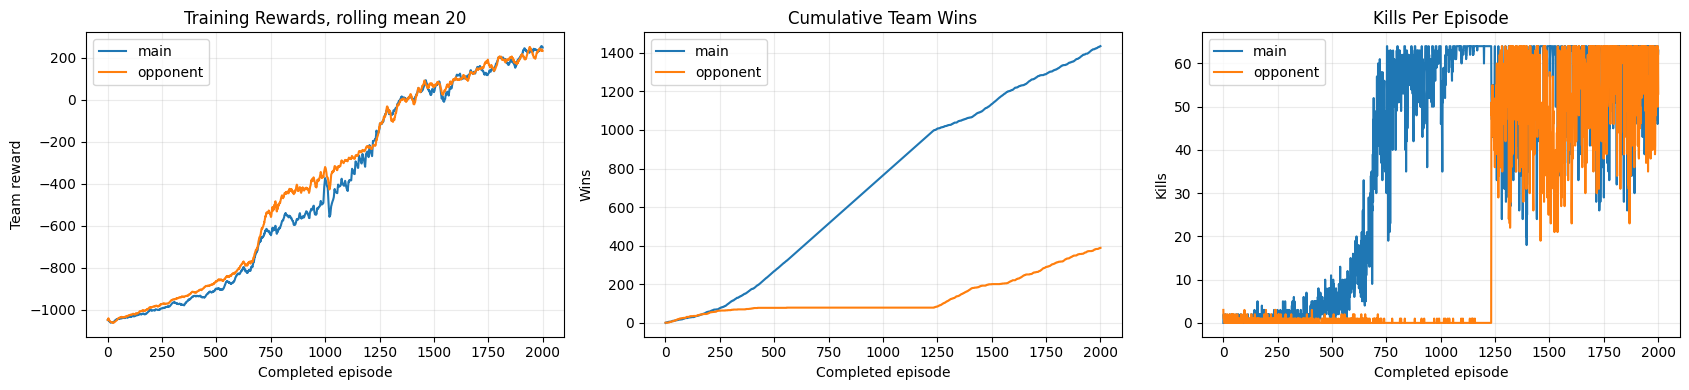

In [4]:
epsilon = 0.5
cfg_eps_0_5 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_5 = train_mfdsrq_from_notebook(cfg_eps_0_5)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_5
plot_mfdsrq_training_curves(result_eps_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_5)

## Decay 0.5 to 0

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-931.630 mean_opponent_reward=-929.383 loss=0.0073 episodes_per_sec=0.31
[mf_srq_torch] episodes=800/2000 mean_main_reward=-208.465 mean_opponent_reward=-187.345 loss=0.0486 episodes_per_sec=0.32
[mf_srq_torch] episodes=1200/2000 mean_main_reward=158.621 mean_opponent_reward=176.575 loss=0.2949 episodes_per_sec=0.34
[mf_srq_torch] episodes=1600/2000 mean_main_reward=232.445 mean_opponent_reward=240.488 loss=0.5150 episodes_per_sec=0.38
[mf_srq_torch] episodes=2000/2000 mean_main_reward=222.531 mean_opponent_reward=239.697 loss=0.4287 episodes_per_sec=0.41

Training complete. 2000 episodes, 544,113 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_5_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_5_to_0/battle_v4/seed42/training_stats.js

{'main': 0.483, 'opponent': 0.437}

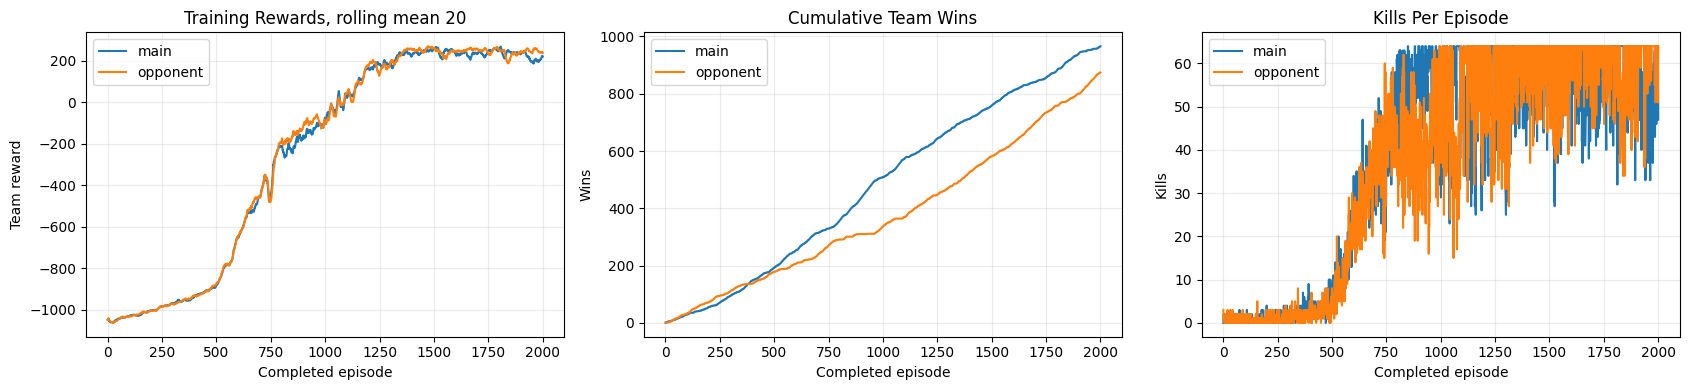

In [6]:
epsilon_start = 0.5
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_0_5_to_0 = dict(BASE_CFG)
cfg_decay_0_5_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_0_5_to_0 = train_mfdsrq_from_notebook(cfg_decay_0_5_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_0_5_to_0
plot_mfdsrq_training_curves(result_decay_0_5_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_0_5_to_0)

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-935.396 mean_opponent_reward=-935.148 loss=0.0395 episodes_per_sec=0.26
[mf_srq_torch] episodes=800/2000 mean_main_reward=-512.002 mean_opponent_reward=-461.770 loss=0.0611 episodes_per_sec=0.26
[mf_srq_torch] episodes=1200/2000 mean_main_reward=34.631 mean_opponent_reward=31.473 loss=0.0842 episodes_per_sec=0.26
[mf_srq_torch] episodes=1600/2000 mean_main_reward=223.595 mean_opponent_reward=251.817 loss=0.4859 episodes_per_sec=0.28
[mf_srq_torch] episodes=2000/2000 mean_main_reward=261.627 mean_opponent_reward=209.099 loss=0.5373 episodes_per_sec=0.32

Training complete. 2000 episodes, 596,775 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_75_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_75_to_0/battle_v4/seed42/training_stats.js

{'main': 0.541, 'opponent': 0.372}

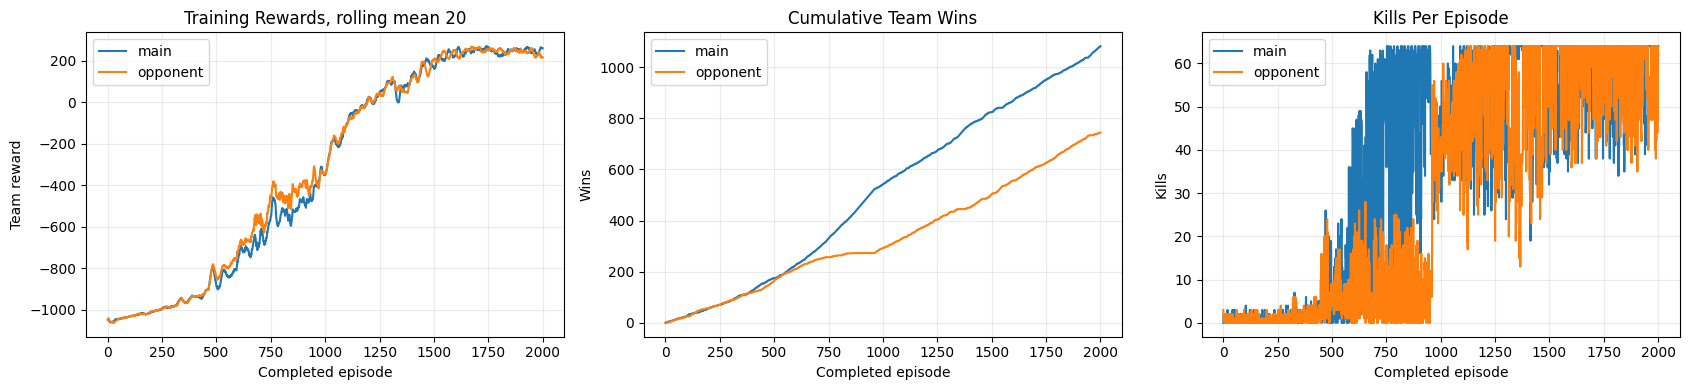

In [7]:
# Robust epsilon schedule: 0.75 -> 0
epsilon_start = 0.75
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_0_75_to_0 = dict(BASE_CFG)
cfg_decay_0_75_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_0_75_to_0 = train_mfdsrq_from_notebook(cfg_decay_0_75_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_0_75_to_0
plot_mfdsrq_training_curves(result_decay_0_75_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_0_75_to_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-965.483 mean_opponent_reward=-921.859 loss=0.0453 episodes_per_sec=0.20
[mf_srq_torch] episodes=800/2000 mean_main_reward=-467.628 mean_opponent_reward=-451.334 loss=0.1326 episodes_per_sec=0.22
[mf_srq_torch] episodes=1200/2000 mean_main_reward=68.901 mean_opponent_reward=87.512 loss=0.1495 episodes_per_sec=0.24
[mf_srq_torch] episodes=1600/2000 mean_main_reward=270.095 mean_opponent_reward=227.182 loss=0.4717 episodes_per_sec=0.26
[mf_srq_torch] episodes=2000/2000 mean_main_reward=232.001 mean_opponent_reward=263.315 loss=0.4981 episodes_per_sec=0.29

Training complete. 2000 episodes, 568,529 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_1_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_1_to_0/battle_v4/seed42/training_stats.json
Sav

{'main': 0.5105, 'opponent': 0.4}

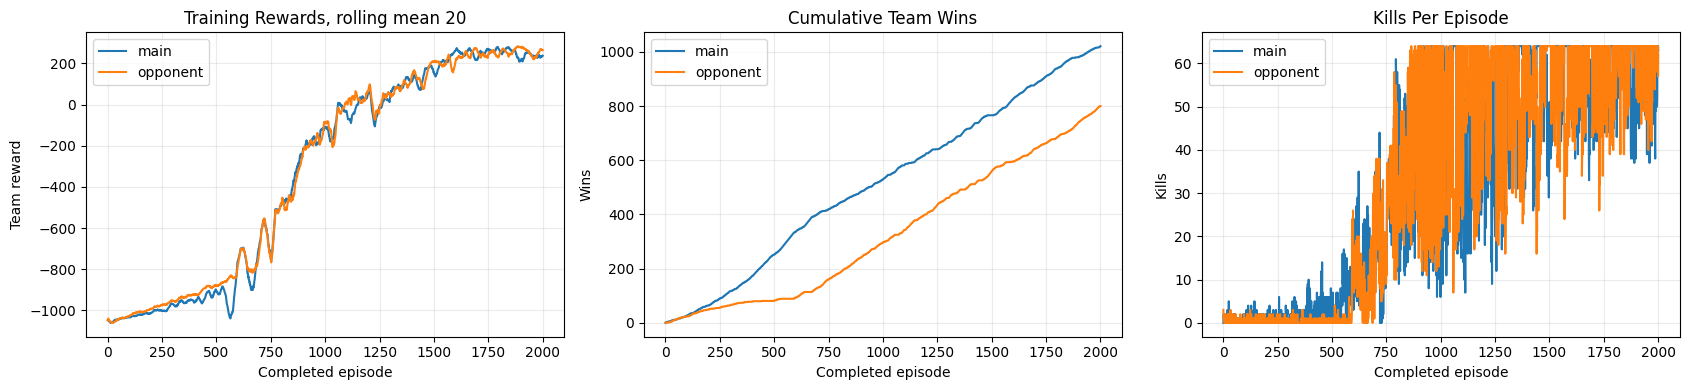

In [8]:
# Robust epsilon schedule: 1 -> 0
epsilon_start = 1.0
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_1_0_to_0 = dict(BASE_CFG)
cfg_decay_1_0_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_1_0_to_0 = train_mfdsrq_from_notebook(cfg_decay_1_0_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_1_0_to_0
plot_mfdsrq_training_curves(result_decay_1_0_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_1_0_to_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-857.517 mean_opponent_reward=-847.911 loss=0.0118 episodes_per_sec=0.31
[mf_srq_torch] episodes=800/2000 mean_main_reward=101.781 mean_opponent_reward=70.579 loss=0.3858 episodes_per_sec=0.31
[mf_srq_torch] episodes=1200/2000 mean_main_reward=177.040 mean_opponent_reward=203.671 loss=0.3764 episodes_per_sec=0.34
[mf_srq_torch] episodes=1600/2000 mean_main_reward=243.285 mean_opponent_reward=246.257 loss=0.4230 episodes_per_sec=0.36
[mf_srq_torch] episodes=2000/2000 mean_main_reward=229.862 mean_opponent_reward=238.921 loss=0.3519 episodes_per_sec=0.37

Training complete. 2000 episodes, 477,009 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_01_to_0_5/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_01_to_0_5/battle_v4/seed42/training_stats.json
Saved 

{'main': 0.4265, 'opponent': 0.508}

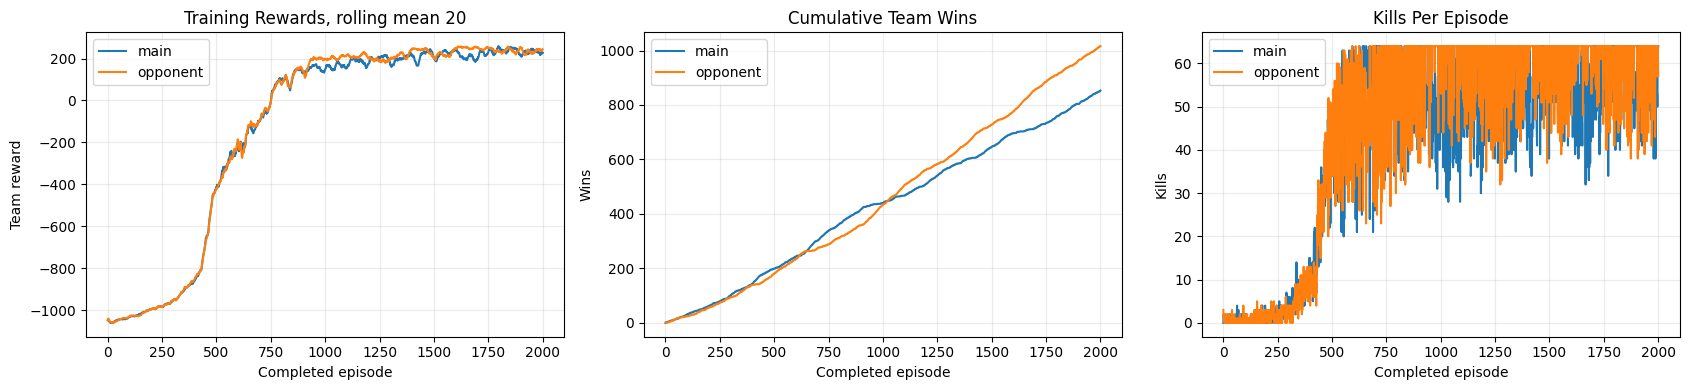

In [9]:
# Robust epsilon schedule: 0.01 -> 0.5
epsilon_start = 0.01
epsilon_end = 0.5
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_01_to_0_5 = dict(BASE_CFG)
cfg_ramp_0_01_to_0_5.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_01_to_0_5 = train_mfdsrq_from_notebook(cfg_ramp_0_01_to_0_5)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_01_to_0_5
plot_mfdsrq_training_curves(result_ramp_0_01_to_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_01_to_0_5)


In [ ]:
# Robust epsilon schedule: 0.01 -> 1
epsilon_start = 0.01
epsilon_end = 1.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_01_to_1_0 = dict(BASE_CFG)
cfg_ramp_0_01_to_1_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_01_to_1_0 = train_mfdsrq_from_notebook(cfg_ramp_0_01_to_1_0)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_01_to_1_0
plot_mfdsrq_training_curves(result_ramp_0_01_to_1_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_01_to_1_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-873.414 mean_opponent_reward=-877.989 loss=0.0073 episodes_per_sec=0.46


In [ ]:
# Robust epsilon schedule: 0.1 -> 0.5
epsilon_start = 0.1
epsilon_end = 0.5
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_1_to_0_5 = dict(BASE_CFG)
cfg_ramp_0_1_to_0_5.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_1_to_0_5 = train_mfdsrq_from_notebook(cfg_ramp_0_1_to_0_5)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_1_to_0_5
plot_mfdsrq_training_curves(result_ramp_0_1_to_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_1_to_0_5)


In [ ]:
# Robust epsilon schedule: 0.1 -> 1
epsilon_start = 0.1
epsilon_end = 1.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_1_to_1_0 = dict(BASE_CFG)
cfg_ramp_0_1_to_1_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_1_to_1_0 = train_mfdsrq_from_notebook(cfg_ramp_0_1_to_1_0)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_1_to_1_0
plot_mfdsrq_training_curves(result_ramp_0_1_to_1_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_1_to_1_0)
